In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf

In [8]:
df = pd.read_csv(
    "..\data\processed\master_data.csv",
    index_col="timestamp",
    parse_dates=True
)

(8759, 9)
open            float64
high            float64
low             float64
close           float64
volume          float64
funding_rate    float64
fear_greed      float64
dxy             float64
nasdaq          float64
dtype: object


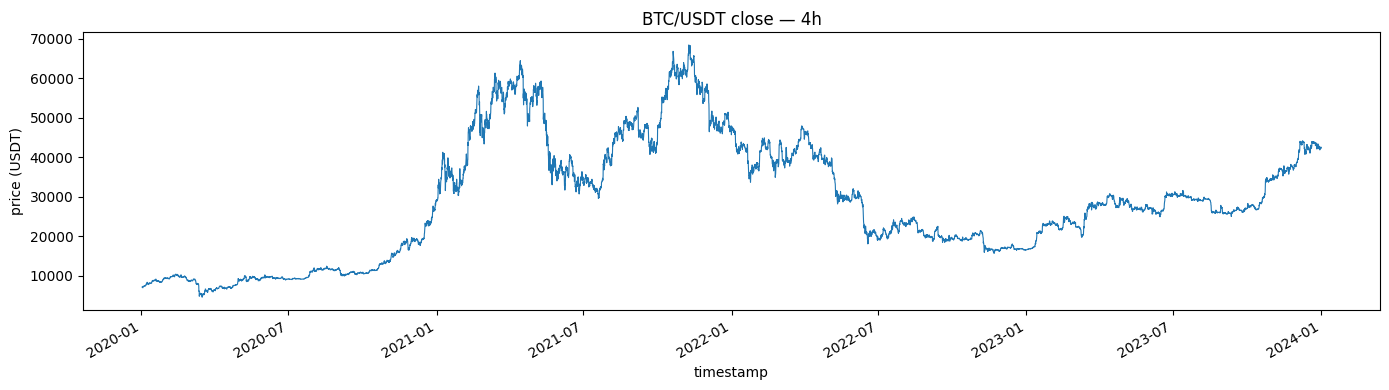

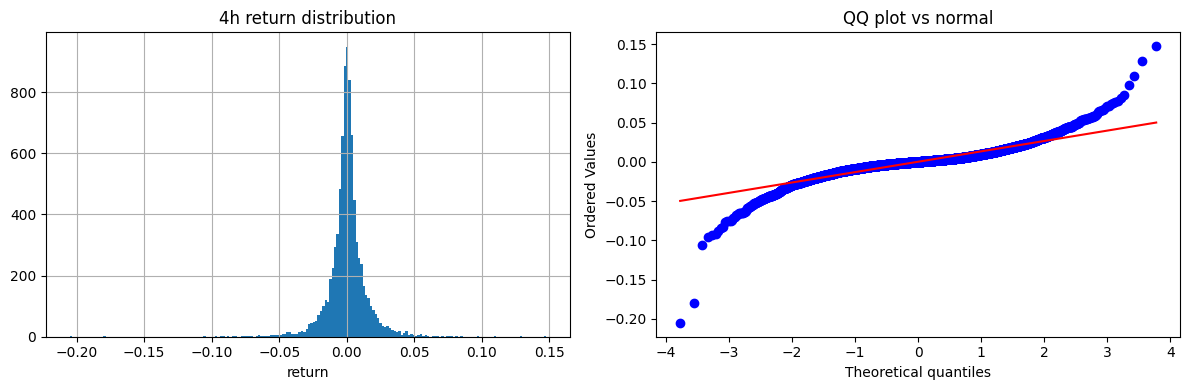

skew     : -0.4558
kurtosis : 15.7452


In [9]:
# === 1. shape & types ===
print(df.shape)
print(df.dtypes)

# === 2. price chart ===
fig, ax = plt.subplots(figsize=(14, 4))
df["close"].plot(ax=ax, linewidth=0.8)
ax.set_title("BTC/USDT close — 4h")
ax.set_ylabel("price (USDT)")
plt.tight_layout()
plt.show()

# === 3. return distribution ===
returns = df["close"].pct_change().dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

returns.hist(bins=200, ax=axes[0])
axes[0].set_title("4h return distribution")
axes[0].set_xlabel("return")

stats.probplot(returns, dist="norm", plot=axes[1])
axes[1].set_title("QQ plot vs normal")

plt.tight_layout()
plt.show()

print(f"skew     : {returns.skew():.4f}")
print(f"kurtosis : {returns.kurtosis():.4f}")

In [10]:
# test on price
adf_price = adfuller(df["close"].dropna())
print(f"ADF price     — stat: {adf_price[0]:.4f}  p-value: {adf_price[1]:.4f}")

# test on log returns
log_returns = np.log(df["close"] / df["close"].shift(1)).dropna()
adf_returns = adfuller(log_returns)
print(f"ADF log ret   — stat: {adf_returns[0]:.4f}  p-value: {adf_returns[1]:.4f}")

# test on funding rate
adf_funding = adfuller(df["funding_rate"].dropna())
print(f"ADF funding   — stat: {adf_funding[0]:.4f}  p-value: {adf_funding[1]:.4f}")

ADF price     — stat: -1.7336  p-value: 0.4139
ADF log ret   — stat: -14.6396  p-value: 0.0000
ADF funding   — stat: -7.1909  p-value: 0.0000


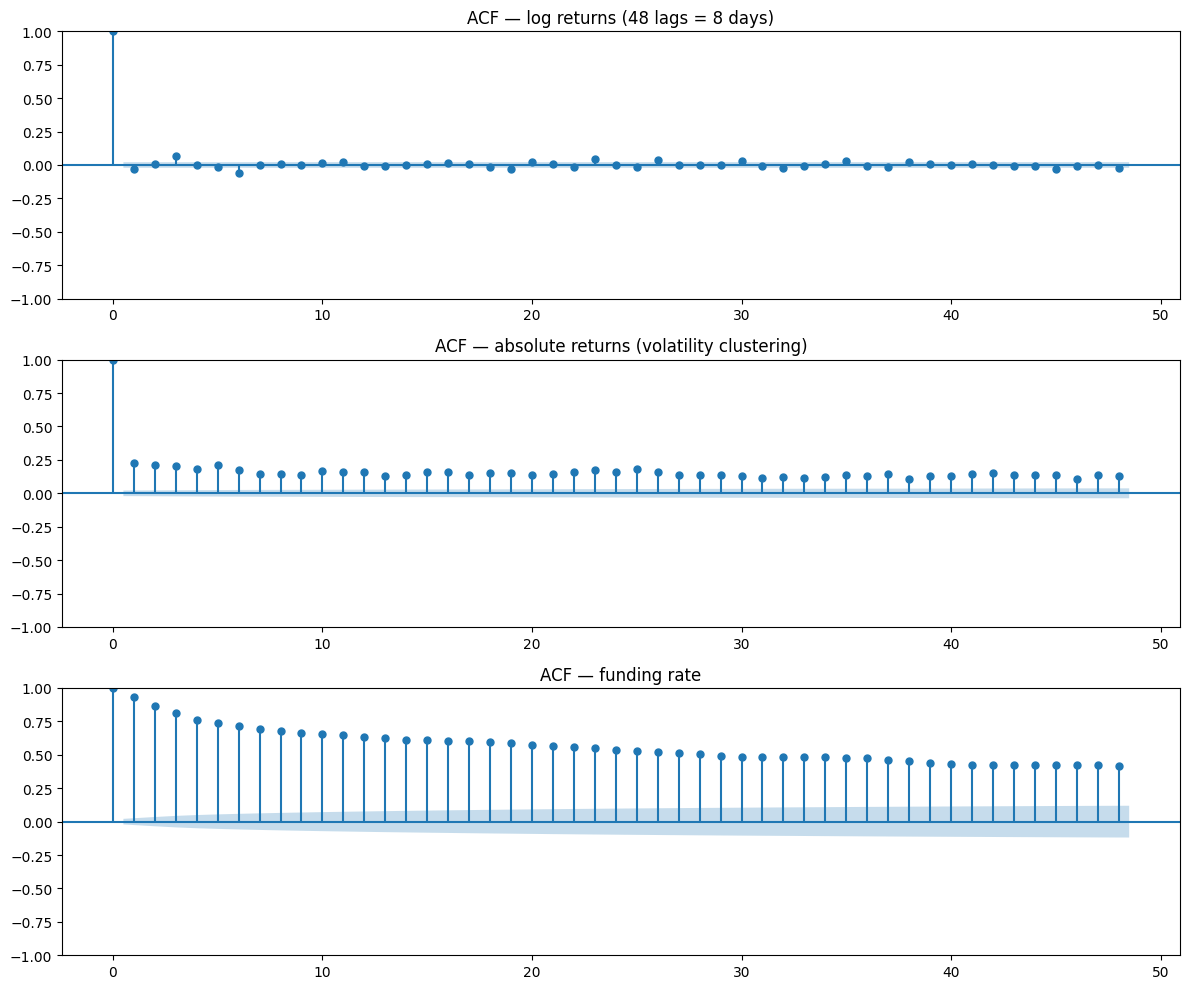

In [11]:
log_returns = np.log(df["close"] / df["close"].shift(1)).dropna()

fig, axes = plt.subplots(3, 1, figsize=(12, 10))

# returns autocorrelation
plot_acf(log_returns, lags=48, ax=axes[0], alpha=0.05)
axes[0].set_title("ACF — log returns (48 lags = 8 days)")

# absolute returns (volatility clustering)
plot_acf(log_returns.abs(), lags=48, ax=axes[1], alpha=0.05)
axes[1].set_title("ACF — absolute returns (volatility clustering)")

# funding rate
plot_acf(df["funding_rate"].dropna(), lags=48, ax=axes[2], alpha=0.05)
axes[2].set_title("ACF — funding rate")

plt.tight_layout()
plt.show()